In [1]:
!pip install statsbombpy pandas matplotlib


   -------- ------------------------------- 1/5 [typeguard]
   ---------------- ----------------------- 2/5 [requests-cache]
   ---------------------------------------- 5/5 [statsbombpy]



In [2]:
from statsbombpy import sb
import pandas as pd
import matplotlib.pyplot as plt

# Βλέπουμε ποια competitions είναι διαθέσιμα δωρεάν
competitions = sb.competitions()
print(competitions[['competition_name', 'season_name', 'competition_id', 'season_id']])


C:\Users\sot\anaconda3\Lib\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


          competition_name season_name  competition_id  season_id
0            1. Bundesliga   2023/2024               9        281
1            1. Bundesliga   2015/2016               9         27
2   African Cup of Nations        2023            1267        107
3         Champions League   2018/2019              16          4
4         Champions League   2017/2018              16          1
..                     ...         ...             ...        ...
70      UEFA Europa League   1988/1989              35         75
71       UEFA Women's Euro        2025              53        315
72       UEFA Women's Euro        2022              53        106
73       Women's World Cup        2023              72        107
74       Women's World Cup        2019              72         30

[75 rows x 4 columns]


In [3]:
# Φορτώνουμε όλους τους αγώνες του Champions League 2017/2018
matches = sb.matches(competition_id=16, season_id=1)
print(f"Συνολικοί αγώνες: {len(matches)}")
print(matches[['match_id', 'home_team', 'away_team', 'home_score', 'away_score']].head(10))

C:\Users\sot\anaconda3\Lib\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


Συνολικοί αγώνες: 1
   match_id    home_team  away_team  home_score  away_score
0     18245  Real Madrid  Liverpool           3           1


In [4]:
# Φορτώνουμε όλα τα events του τελικού
events = sb.events(match_id=18245)
print(f"Συνολικά events: {len(events)}")
print(events['type'].value_counts().head(10))

C:\Users\sot\anaconda3\Lib\site-packages\statsbombpy\api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


Συνολικά events: 3497
type
Pass             1033
Ball Receipt*     978
Carry             796
Pressure          226
Ball Recovery      95
Duel               56
Block              36
Clearance          33
Goal Keeper        32
Dribble            29
Name: count, dtype: int64


In [5]:
# Φιλτράρουμε μόνο τα shots
shots = events[events['type'] == 'Shot'].copy()

print(f"Συνολικά shots: {len(shots)}")
print(shots[['player', 'team', 'shot_statsbomb_xg', 'shot_outcome']].to_string())


Συνολικά shots: 28
                                   player         team  shot_statsbomb_xg shot_outcome
3400                  Georginio Wijnaldum    Liverpool           0.036399      Blocked
3401                        Mohamed Salah    Liverpool           0.027976      Blocked
3402  Roberto Firmino Barbosa de Oliveira    Liverpool           0.075361        Off T
3403       Marcelo Vieira da Silva Júnior  Real Madrid           0.023376        Off T
3404                  James Philip Milner    Liverpool           0.043772      Blocked
3405                        Mohamed Salah    Liverpool           0.065653      Blocked
3406                           Sadio Mané    Liverpool           0.057769      Blocked
3407  Cristiano Ronaldo dos Santos Aveiro  Real Madrid           0.012569        Off T
3408                      Virgil van Dijk    Liverpool           0.248677        Off T
3409  Roberto Firmino Barbosa de Oliveira    Liverpool           0.083349      Blocked
3410               Trent

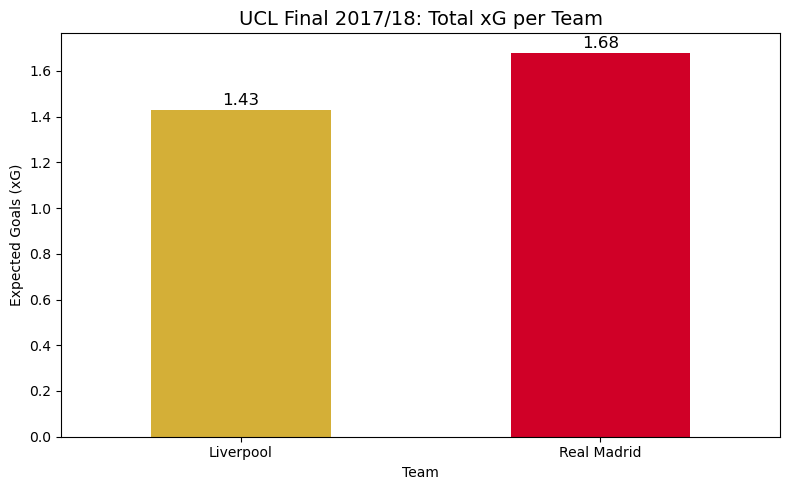

In [6]:
# Συνολικό xG ανά ομάδα
xg_per_team = shots.groupby('team')['shot_statsbomb_xg'].sum().round(2)

fig, ax = plt.subplots(figsize=(8, 5))
xg_per_team.plot(kind='bar', ax=ax, color=['#d4af37', '#d00027'])
ax.set_title('UCL Final 2017/18: Total xG per Team', fontsize=14)
ax.set_xlabel('Team')
ax.set_ylabel('Expected Goals (xG)')
ax.set_xticklabels(xg_per_team.index, rotation=0)
for i, v in enumerate(xg_per_team):
    ax.text(i, v + 0.02, str(v), ha='center', fontsize=12)
plt.tight_layout()
plt.show()
